In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
import torch


In [2]:
import pickle
with open("/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/saved_problems/Knapsack/Knapsack_39.pkl",'rb') as df:
    prob=pickle.load(df)

/home/genghaoyu/anaconda3/envs/py38_th20/lib/python3.8/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


In [3]:
prob

In [4]:
Xs_train, Ys_train, params_train = prob.get_train_data()

In [16]:
Ys_train

tensor([[ 5.,  2.,  6.,  ...,  7., 11.,  3.],
        [ 5.,  4.,  8.,  ...,  5.,  7.,  3.],
        [ 3.,  4.,  9.,  ..., 14., 17.,  2.],
        ...,
        [ 2.,  3.,  5.,  ...,  8.,  6.,  2.],
        [ 3.,  4.,  3.,  ...,  1.,  1.,  1.],
        [ 2.,  4.,  2.,  ...,  2.,  1.,  5.]])

In [33]:
Xs_test, Ys_test, params_test = prob.get_test_data()

In [23]:
Ys_test.shape, Ys_test

(torch.Size([200, 20]),
 tensor([[ 4.,  3.,  3.,  ...,  2.,  5.,  6.],
         [13.,  4.,  7.,  ..., 18., 39.,  6.],
         [ 2.,  2.,  1.,  ...,  4.,  5.,  6.],
         ...,
         [ 4.,  3.,  2.,  ...,  1.,  2.,  6.],
         [ 3.,  3.,  6.,  ..., 10., 10.,  6.],
         [ 2.,  2.,  3.,  ...,  3.,  1.,  2.]]))

In [24]:
def get_pred(prefix, prob="knapsack-gen-ood"):
    return torch.load(f"/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/timed_logs/{prefix}/tensors/preds.pt")
mse_iid_pred = get_pred("knapsack-gen-ood/mse/time-new-IID-30-qualitative/2024-08-06 09-34-09.820276")

/tmp/ipykernel_36331/88954198.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f"/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/timed_logs/{pre

In [25]:
mse_iid_pred, mse_iid_pred.shape

(tensor([[ 0.2233,  0.4365,  0.4542,  ..., -0.1454,  0.4784,  0.1622],
         [-0.0614,  0.4839,  0.7311,  ..., -0.2219,  0.6647, -0.0318],
         [ 0.1850,  0.2749, -0.0235,  ..., -0.1267,  0.1957, -0.0398],
         ...,
         [ 0.3216,  0.1976,  0.4599,  ..., -0.1369,  0.4274,  0.2155],
         [-0.0393,  0.4259,  0.4617,  ..., -0.1942,  0.6121, -0.0907],
         [ 0.2324, -0.1340,  0.1184,  ..., -0.0507,  0.2817, -0.1671]]),
 torch.Size([200, 20]))

In [26]:
mse_ood_erm_pred =  get_pred("knapsack-gen-ood/mse/time-new-OOD-ERM-30-qualitative/2024-08-06 10-27-38.694158")
mse_ood_eerm_pred = get_pred("knapsack-gen-ood/mse/time-new-OOD-30-EERM-qualitative/2024-08-06 11-06-55.678218")

/tmp/ipykernel_36331/88954198.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f"/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/timed_logs/{pre

In [13]:
mse_ood_erm_pred

tensor([[1.8741e+01, 1.3148e-01, 1.3818e+01,  ..., 8.0787e+01, 8.3703e+01,
         8.0840e+01],
        [4.5926e+01, 3.5733e-01, 3.8856e+01,  ..., 2.2194e+02, 2.2845e+02,
         2.2080e+02],
        [9.9011e+00, 1.4676e-01, 4.6097e+00,  ..., 4.6052e+01, 4.7546e+01,
         4.5590e+01],
        ...,
        [5.0254e+00, 3.1318e-02, 3.7582e-01,  ..., 1.4236e+01, 1.4871e+01,
         1.4395e+01],
        [3.3091e+01, 2.6787e-01, 3.2051e+01,  ..., 1.6780e+02, 1.7284e+02,
         1.6679e+02],
        [2.1905e+00, 2.8763e-02, 2.3426e+00,  ..., 1.0348e+01, 1.0914e+01,
         1.0189e+01]])

In [27]:
mse_ood_eerm_pred

tensor([[12.9514, -0.8237, 13.3293,  ..., 13.3382, 14.4687, 13.8232],
        [32.9528, -0.3794, 34.8892,  ..., 36.1685, 37.3962, 34.8355],
        [ 7.3125, -0.4409,  6.7540,  ...,  7.4753,  7.9993,  7.4406],
        ...,
        [ 5.4575, -0.6635,  4.9119,  ...,  4.7413,  5.4384,  5.4370],
        [24.6763, -0.4311, 26.2801,  ..., 27.2298, 28.1341, 25.8228],
        [ 3.2935, -0.7311,  3.1383,  ...,  3.2248,  3.5851,  3.0498]])

In [28]:
Ys_test[0], mse_ood_erm_pred[0], mse_ood_eerm_pred[0]

(tensor([ 4.,  3.,  3.,  3.,  3., 12.,  2.,  3.,  6.,  3., 11.,  1.,  7.,  2.,
         10.,  9.,  3.,  2.,  5.,  6.]),
 tensor([18.7414,  0.1315, 13.8177, 17.5921, 83.2434, 79.4360, 74.2997, 78.9107,
         75.9479, 77.3463, 83.7440, 84.2311, 78.7149, 74.9553, 81.7211, 82.8773,
         81.6086, 80.7872, 83.7030, 80.8405]),
 tensor([12.9514, -0.8237, 13.3293, 12.9565, 14.0610, 12.8658, 13.2614, 12.1708,
         14.0433, 14.0420, 15.4310, 14.9965, 14.6233, 13.8080, 13.5315, 14.3896,
         13.8023, 13.3382, 14.4687, 13.8232]))

In [22]:
params_test[0], params_test[0].sum()

(tensor([6.4300, 3.2500, 7.5400, 4.8300, 7.1700, 5.2000, 3.0300, 6.7200, 3.5200,
         7.7000, 6.5700, 7.8000, 5.7800, 7.0100, 5.3900, 7.3700, 7.3100, 6.3300,
         3.3900, 7.5300]),
 tensor(119.8700))

In [29]:
spo_iid_pred = get_pred("knapsack-gen-ood/spo/new-IID-30-qualitative/2024-08-06 10-21-23.702724")
spo_ood_erm_pred = get_pred("knapsack-gen-ood/spo/new-OOD-ERM-30-qualitative/2024-08-06 11-07-11.790697")
spo_ood_eerm_pred = get_pred("knapsack-gen-ood/spo/new-OOD-30-EERM-qualitative/2024-08-06 11-39-12.843253")

/tmp/ipykernel_36331/88954198.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f"/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/timed_logs/{pre

In [30]:
spo_iid_pred[0], spo_ood_erm_pred[0], spo_ood_eerm_pred[0]

(tensor([ 8.2278,  3.4226,  3.7107,  3.3654,  4.8112,  9.2595,  1.8228,  0.9608,
          5.1662,  1.9615,  8.7918, -1.3511,  6.6185, -2.0098,  7.8737,  5.9532,
          3.1857, -1.2830,  5.4077,  6.9200]),
 tensor([-3.0782, -1.9217, -1.4460, -1.4152, 30.8233, 27.5888,  6.2217, 18.3253,
          7.7047,  0.9942, 28.9285, 16.7770,  7.6065,  0.0701, 27.2332, 27.7858,
         30.6474, 21.8017, 31.5980, 27.0000]),
 tensor([-4733.1782,  -238.8525,  -318.2349, -1879.6039,  2267.3684,   793.3023,
          -820.9553,  -896.0048,  -176.9134,   543.0200,   892.8482,  -935.8640,
          1084.3853, -1330.8376,  1370.7933,  1076.0039,   985.7263,   -18.1761,
          1169.0273,  1060.3379]))

In [31]:
Ys_test[0]

tensor([ 4.,  3.,  3.,  3.,  3., 12.,  2.,  3.,  6.,  3., 11.,  1.,  7.,  2.,
        10.,  9.,  3.,  2.,  5.,  6.])

In [6]:
prob.weights

tensor([6.4300, 3.2500, 7.5400, 4.8300, 7.1700, 5.2000, 3.0300, 6.7200, 3.5200,
        7.7000, 6.5700, 7.8000, 5.7800, 7.0100, 5.3900, 7.3700, 7.3100, 6.3300,
        3.3900, 7.5300])

In [7]:
prob.capacity

30

In [5]:
import gurobipy as gp  # pylint: disable=no-name-in-module

from gurobipy import GRB  # pylint: disable=no-name-in-module

from openpto.method.Solvers.grb.grbSolver import optGrbSolver

# optimization model
class KPGrbSolver(optGrbSolver):
    def __init__(self, weights, capacity, modelSense, **kwargs):
        super().__init__(modelSense)
        self._model, self.z = self._getModel(weights, capacity)
        # turn off output
        self._model.Params.outputFlag = 0

    def _getModel(self, weights, capacity):
        num_items = len(weights)
        m = gp.Model()
        x = m.addVars(num_items, name="x", vtype=GRB.BINARY)
        m.modelSense = self.modelSense
        m.addConstr(
            gp.quicksum([weights[i] * x[i] for i in range(num_items)]) <= capacity
        )
        return m, x

    def setObj(self, c):
        if len(c) != self.num_vars:
            raise ValueError("Size of cost vector cannot match vars.")
        obj = gp.quicksum(c[i] * self.z[k] for i, k in enumerate(self.z))
        self._model.setObjective(obj)

    def solve(self, y, **kwargs):
        self.setObj(y)
        self._model.update()
        self._model.optimize()
        others = {}
        return [self.z[k].x for k in self.z], self._model.objVal, others

In [9]:
solver = KPGrbSolver(prob.weights, prob.capacity, GRB.MAXIMIZE)

Restricted license - for non-production use only - expires 2025-11-24


In [22]:
sol, obj, _ = solver.solve(Ys_test[0])
np.where(np.array(sol) == 1)[0]

array([ 5,  8, 10, 12, 14, 18])

## 可视化

In [76]:
def visual_eerm(preds, Ys_test, prob_idx):
    sol, obj, _ = solver.solve(preds[prob_idx])
    sol0 = np.where(np.array(sol) == 1)[0]
    # print(sol0)
    dq = (Ys_test[prob_idx] * np.array(sol)).sum(-1).item()
    return sol0, dq

In [90]:
print(Ys_test[0])

tensor([ 4.,  3.,  3.,  3.,  3., 12.,  2.,  3.,  6.,  3., 11.,  1.,  7.,  2.,
        10.,  9.,  3.,  2.,  5.,  6.])


In [77]:
# spo_iid_pred[0], spo_ood_erm_pred[0], spo_ood_eerm_pred[0]
visual_eerm(Ys_test, Ys_test, prob_idx=70)

(array([ 1,  3,  6,  9, 11, 18]), 19.0)


In [81]:
# spo_iid_pred[0], spo_ood_erm_pred[0], spo_ood_eerm_pred[0]
visual_eerm(spo_ood_erm_pred, Ys_test, prob_idx= 70)

(array([ 5,  6, 10, 14, 17, 18]), 24.0)

In [80]:
# spo_iid_pred[0], spo_ood_erm_pred[0], spo_ood_eerm_pred[0]
visual_eerm(spo_ood_eerm_pred, Ys_test, prob_idx= 70)

(array([ 4,  6,  7, 16, 18]), 35.0)

In [83]:
Ys_test[70]

tensor([ 2.,  2.,  4.,  1.,  6.,  4.,  9., 12.,  5.,  1.,  4.,  6.,  1., 13.,
         2.,  3.,  6.,  3.,  2.,  4.])

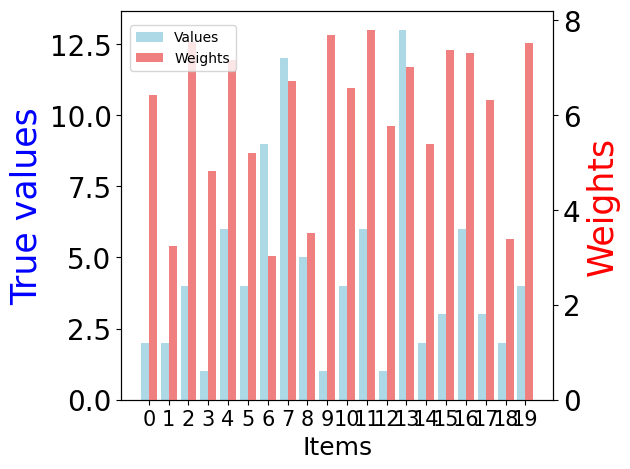

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# 样本数据
values =  Ys_test[70]
weights = prob.weights
items = list(range(len(Ys_test[70])))

x = np.arange(len(items))  # the label locations
width = 0.4  # the width of the bars

fig, ax1 = plt.subplots()
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 20

# 在第一个y轴上绘制values的柱状图
bars1 = ax1.bar(x - width/2, values, width, label='Values', color='lightblue')

# 设置第一个y轴的标签
ax1.set_xlabel('Items', fontsize=18)
ax1.set_ylabel('True values', color='blue', fontsize=25)
ax1.tick_params(axis='y')#, labelcolor='lightblue')
ax1.set_xticks(x)
ax1.set_xticklabels(items)
# ax1.set_yticks(fontsize=20)

# 创建第二个y轴并绘制weights的柱状图
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, weights, width, label='Weights', color='lightcoral')

# 设置第二个y轴的标签
ax2.set_ylabel('Weights', color='red', fontsize=25)
ax2.tick_params(axis='y')#, labelcolor='lightcoral')

# 添加图例
fig.tight_layout()
fig.legend(loc='upper left', bbox_to_anchor=(0.2,0.95))

# plt.title('Values and Weights of Items in 70-th instance')
plt.savefig("/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_quali/kp_instance.pdf")
plt.show()


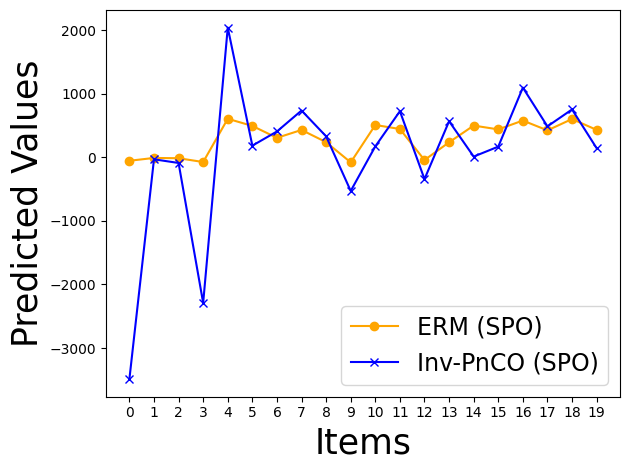

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# 样本数据

# true_values = [10, 20, 30, 40, 50]
# predicted_values1 = [12, 22, 28, 35, 48]
# predicted_values2 = [8, 18, 32, 38, 55]
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 20

true_values = Ys_test[70]
predicted_values1 = spo_ood_erm_pred[70]
predicted_values2 = spo_ood_eerm_pred[70]

items = list(range(len(true_values)))

x = np.arange(len(items))  # the label locations
width = 0.35  # the width of the bars

plt.style.use('default')

fig, ax = plt.subplots()

# 绘制真实值的柱状图
# bars = ax.bar(x - width/2, true_values, width, label='True Values')

# 绘制两组预测值的折线图
line1, = ax.plot(x, predicted_values1*20, color='orange', marker='o', label='ERM (SPO)')
line2, = ax.plot(x, predicted_values2, color='blue', marker='x', label='Inv-PnCO (SPO)')

# 添加一些文本标签
ax.set_xlabel('Items', fontsize=25)
ax.set_ylabel('Predicted Values', fontsize=25)
# ax.set_title('Knapsack Problem Visualization')
ax.set_xticks(x)
ax.set_xticklabels(items)
ax.legend(fontsize = 17)

# 自动调整标签
fig.tight_layout()
plt.savefig("/mnt/nas/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_quali/inv_pnco.pdf")
plt.show()
